# Drought Analysis with SSI

SynHydro provides the **Standardized Streamflow Index (SSI)** for
characterizing drought from streamflow data. This tutorial covers the
SSI calculation and drought event extraction workflow.

> **Note:** Run this notebook from the `examples/` directory. Figures are saved to `figures/07_drought_analysis/` and data outputs to `outputs/07_drought_analysis/` (both are gitignored).

In [1]:
from pathlib import Path

FIG_DIR = Path("figures") / "07_drought_analysis"
OUT_DIR = Path("outputs") / "07_drought_analysis"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

## Calculate SSI on observed data

SSI transforms raw flows into standardized anomalies by fitting a probability
distribution within a rolling window. Values below -1 indicate drought;
below -2 is extreme.

In [2]:
import synhydro

Q_daily = synhydro.load_example_data()
Q_monthly = Q_daily.resample("MS").sum()
site = Q_monthly.columns[0]

ssi_calc = synhydro.SSI(dist="gamma", timescale=12, fit_freq="ME")
ssi_calc.fit(Q_monthly[site])
ssi = ssi_calc.get_training_ssi()

print(f"SSI mean: {ssi.mean():.3f}")   # ~0
print(f"SSI std:  {ssi.std():.3f}")     # ~1

SSI mean: -0.000
SSI std:  1.001


## Extract drought events

`get_drought_metrics` identifies contiguous periods where SSI stays below -1:

In [3]:
metrics = synhydro.get_drought_metrics(ssi)
print(metrics[["start", "end", "duration", "severity", "avg_severity"]].head())

       start        end  duration  severity  avg_severity
1 1957-04-01 1958-04-01        13 -1.165892     -0.849866
2 1961-09-01 1970-03-01       103 -2.919131     -1.169463
3 1980-02-01 1983-11-01        46 -1.869801     -0.993548
4 1985-02-01 1986-04-01        15 -2.144655     -1.223897
5 1987-03-01 1990-01-01        35 -2.019259     -0.783442


Each row is a drought event with its duration, severity (minimum SSI),
and magnitude (cumulative deficit).

## Visualize ensemble SSI

`plot_ssi_timeseries` computes SSI for each ensemble realization and overlays
the observed SSI, making it easy to compare synthetic and historical drought
behavior. Pass the ensemble (not a training SSI series) along with the
observed flows.

INFO:synhydro.KirschGenerator:Validated data: 964 timesteps, 4 sites, period 1945-01-01 00:00:00 to 2025-04-01 00:00:00


INFO:synhydro.KirschGenerator:Preprocessing complete: 4 sites, 81 years, frequency=MS


INFO:synhydro.KirschGenerator:Fitting complete: 80 years, 4 sites, 12 periods/year


INFO:synhydro.KirschGenerator:Generated 20 realizations of 20 years each


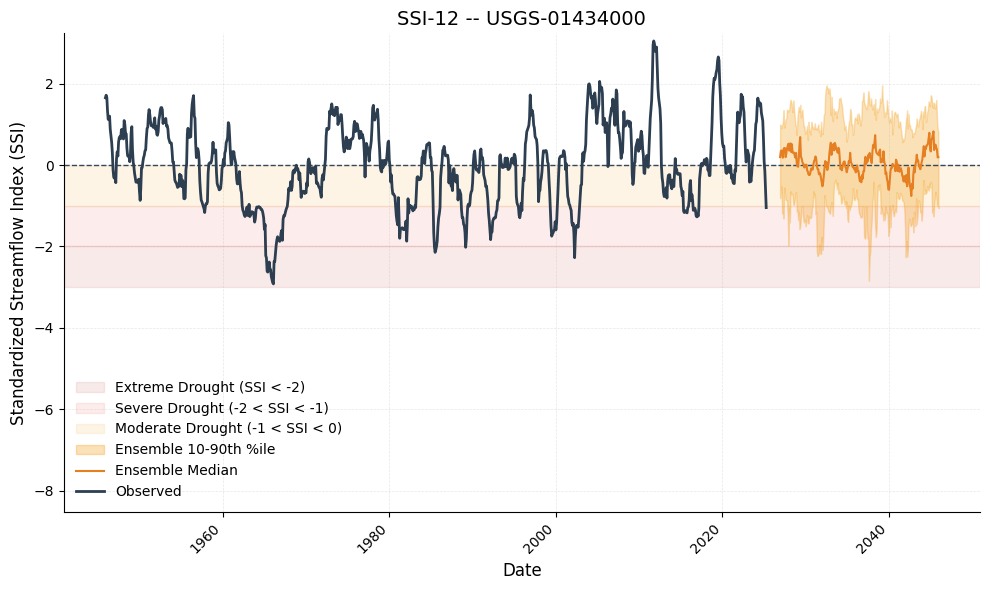

In [4]:
from synhydro.plotting import plot_ssi_timeseries

gen = synhydro.KirschGenerator()
gen.fit(Q_monthly)
ensemble = gen.generate(n_realizations=20, n_years=20, seed=42)

fig, ax = plot_ssi_timeseries(
    ensemble,
    observed=Q_monthly[site],
    site=site,
    window=12,
    title=f"SSI-12 -- {site}",
)
fig.savefig(FIG_DIR / "ssi_with_droughts.png", dpi=150, bbox_inches="tight")

Shaded zones mark moderate (-1 to -1.5), severe (-1.5 to -2), and
extreme (< -2) drought conditions.

> **Tip (Choosing a distribution):** Use `compare_distributions` to rank
> candidate distributions by AIC and Kolmogorov-Smirnov test:

In [5]:
results = synhydro.compare_distributions(
    Q_monthly[site].dropna(),
    distributions=["gamma", "lognorm", "pearson3", "weibull_min", "norm"],
)
print(results)

  distribution  ks_statistic  ks_pvalue  ks_pass           aic           bic  \
0        gamma      0.024951   0.584308     True  20982.299584  20996.878429   
1      lognorm      0.026423   0.510351     True  20982.645317  20997.224162   
2     pearson3      0.024951   0.584309     True  20982.299584  20996.878429   
3  weibull_min      0.037113   0.141228     True  20990.180050  21004.758895   
4         norm      0.050578   0.014729    False  21018.088292  21027.807522   

   log_likelihood  n_params  fit_success error  aic_rank  bic_rank  ks_rank  
0   -10488.149792         3         True  None       1.0       1.0      2.0  
1   -10488.322659         3         True  None       3.0       3.0      3.0  
2   -10488.149792         3         True  None       2.0       2.0      1.0  
3   -10492.090025         3         True  None       4.0       4.0      4.0  
4   -10507.044146         2         True  None       5.0       5.0      5.0  


## Next steps

- **Ensemble validation** - [Tutorial 05](../05_verification/)
- **Algorithm details** - [Kirsch Bootstrap](../../algorithms/kirsch/)

---

**Previous:** [Plotting Walkthrough](../06_plotting/) | **Next:** [Monthly-to-Daily Pipeline](../08_pipeline/)